In [1]:
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader

In [2]:
SEQ_LEN       = 30
PRED_LEN      = 1
BATCH_SIZE    = 32
EPOCHS        = 10
LR            = 1e-3
D_MODEL       = 64
NHEAD         = 4
NUM_LAYERS    = 3
DIM_FF        = 128
DROPOUT       = 0.1
TRAIN_RATIO   = 0.8
PATIENCE      = 5          # early-stopping patience
GRAD_CLIP     = 1.0        # max gradient norm
CHECKPOINT    = "best_stockformer.pt"

In [3]:
dataset_hf = load_dataset("Adilbai/stock-dataset")
df = dataset_hf["train"].to_pandas()

if "Date" in df.columns:
    df = df.sort_values("Date").reset_index(drop=True)


cols_to_drop = [c for c in df.columns if any(
    keyword in c for keyword in ["_lag_", "RSI", "SMA", "EMA", "BB_", "Volume_SMA", "MACD"]
)]
print(f"Dropping {len(cols_to_drop)} derived columns: {cols_to_drop}")
df = df.drop(columns=cols_to_drop, errors="ignore")

# Drop leakage columns
leakage_cols = [c for c in df.columns if "Future" in c]
df = df.drop(columns=leakage_cols)
print(f"Dropped leakage columns: {leakage_cols}")


# Drop near-zero noise columns
df = df.drop(columns=["Dividends", "Stock Splits"], errors="ignore")

# Log-transform volume
# if "Volume" in df.columns:
#     df["Volume"] = np.log1p(df["Volume"])
# Log-transform Volume and ALL volume-derived columns
volume_cols = [c for c in df.columns if "Volume" in c]
print(f"Log-transforming: {volume_cols}")
for col in volume_cols:
    df[col] = np.log1p(df[col].clip(lower=0))  # clip handles any negatives

# Now select numeric (after cleaning, so INPUT_DIM is correct) 
df_numeric = df.select_dtypes(include=[np.number])
print(f"Remaining features: {df_numeric.columns.tolist()}")
print(f"Shape: {df_numeric.shape}")

# Scale: per-ticker if available, otherwise global 
ticker_col = next((c for c in ["Ticker", "Symbol"] if c in df.columns), None)

if ticker_col:
    # Per-ticker chronological split + scaling
    train_parts, val_parts = [], []
    scalers = {}
    val_meta = []
    naive_maes, naive_rmses = [], [] 
    val_pos = 0

    for ticker, group in df.groupby(ticker_col, sort=False):
        grp = group.select_dtypes(include=[np.number])
        
        # Chronological split per ticker
        n = len(grp)
        if n < SEQ_LEN * 2:          # skip tickers too short to be useful
            continue
        split = int(n * TRAIN_RATIO)

        train_grp = grp.iloc[:split].values
        val_grp   = grp.iloc[split:].values

        sc = StandardScaler()
        train_parts.append(sc.fit_transform(train_grp))
        val_parts.append(sc.transform(val_grp))
        scalers[ticker] = sc

        n_val = len(val_grp)
        val_meta.extend([
            (ticker, group.index[split + i], val_pos + i)
            for i in range(n_val)
        ])
        val_pos += n_val

        close_idx = grp.columns.tolist().index("Close")
        open_idx  = grp.columns.tolist().index("Open")
        high_idx  = grp.columns.tolist().index("High")
        low_idx   = grp.columns.tolist().index("Low")

        price_indices = [open_idx, high_idx, low_idx, close_idx]
        naive_preds   = val_grp[:-1][:, price_indices]
        naive_actual  = val_grp[1:][:,  price_indices]
        naive_maes.append(np.mean(np.abs(naive_preds - naive_actual)))
        naive_rmses.append(np.sqrt(np.mean((naive_preds - naive_actual) ** 2)))


    naive_mae  = float(np.mean(naive_maes))   # average across tickers
    naive_rmse = float(np.mean(naive_rmses))
    
    
    train_scaled = np.vstack(train_parts)
    val_scaled   = np.vstack(val_parts)
    scaler = None   # per-ticker scalers stored in dict above
    naive_mae    = float(np.mean(naive_maes))
    naive_rmse   = float(np.mean(naive_rmses))


else:
    # Global fallback — chronological split then scale
    split_idx    = int(len(df_numeric) * TRAIN_RATIO)
    train_raw    = df_numeric.iloc[:split_idx].values
    val_raw      = df_numeric.iloc[split_idx:].values

    scaler       = StandardScaler()
    train_scaled = scaler.fit_transform(train_raw)
    val_scaled   = scaler.transform(val_raw)

    # Baseline testing
    close_idx = df_numeric.columns.tolist().index("Close")
    open_idx  = df_numeric.columns.tolist().index("Open")
    high_idx  = df_numeric.columns.tolist().index("High")
    low_idx   = df_numeric.columns.tolist().index("Low")
    price_indices = [open_idx, high_idx, low_idx, close_idx]
    naive_preds   = val_raw[:-1][:, price_indices]
    naive_actual  = val_raw[1:][:,  price_indices]

    naive_mae  = np.mean(np.abs(naive_preds - naive_actual))
    naive_rmse = np.sqrt(np.mean((naive_preds - naive_actual) ** 2))

    print(f"Naive Baseline (original scale) ")
    print(f"  MAE  : {naive_mae:.4f}")
    print(f"  RMSE : {naive_rmse:.4f}")
    print(f"  (Your model needs to beat these numbers to add value)")

INPUT_DIM = train_scaled.shape[1]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Dropping 46 derived columns: ['SMA_5', 'SMA_10', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'MACD_Histogram', 'RSI', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'BB_Position', 'Volume_SMA', 'Close_lag_1', 'Close_lag_2', 'Close_lag_3', 'Close_lag_5', 'Close_lag_10', 'Volume_lag_1', 'Volume_lag_2', 'Volume_lag_3', 'Volume_lag_5', 'Volume_lag_10', 'Price_Change_lag_1', 'Price_Change_lag_2', 'Price_Change_lag_3', 'Price_Change_lag_5', 'Price_Change_lag_10', 'RSI_lag_1', 'RSI_lag_2', 'RSI_lag_3', 'RSI_lag_5', 'RSI_lag_10', 'MACD_lag_1', 'MACD_lag_2', 'MACD_lag_3', 'MACD_lag_5', 'MACD_lag_10', 'Volatility_lag_1', 'Volatility_lag_2', 'Volatility_lag_3', 'Volatility_lag_5', 'Volatility_lag_10']
Dropped leakage columns: ['Future_Return_1d', 'Future_Up_1d', 'Future_Category_1d', 'Future_Return_5d', 'Future_Up_5d', 'Future_Category_5d', 'Future_Return_10d', 'Future_Up_10d', 'Future_Category_10d', 'Future_Return_20d', 'Future_Up_20d', 'Future_Category_20d']
Log-transformin

In [4]:
# class StockDataset(Dataset):
#     def __init__(self, data: np.ndarray, seq_len: int, pred_len: int):
#         self.data     = torch.tensor(data, dtype=torch.float32)
#         self.seq_len  = seq_len
#         self.pred_len = pred_len

#     def __len__(self):
#         return len(self.data) - self.seq_len - self.pred_len + 1

#     def __getitem__(self, idx):
        
#         x = self.data[idx : idx + self.seq_len]
#         y = self.data[idx + self.seq_len : idx + self.seq_len + self.pred_len]
#         return x, y


# train_ds = StockDataset(train_scaled, SEQ_LEN, PRED_LEN)
# val_ds   = StockDataset(val_scaled,   SEQ_LEN, PRED_LEN)

# train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False,  drop_last=True)
# val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# Build a list of which ticker each val_scaled row belongs to
val_ticker_map = [ticker for ticker, df_idx, pos in val_meta]

class StockDataset(Dataset):
    def __init__(self, data, seq_len, pred_len, ticker_map=None):
        self.data       = torch.tensor(data, dtype=torch.float32)
        self.seq_len    = seq_len
        self.pred_len   = pred_len
        self.ticker_map = ticker_map  # list of ticker per row, or None

        # Precompute valid indices — skip any window that crosses a ticker boundary
        self.valid_indices = []
        for idx in range(len(self.data) - seq_len - pred_len + 1):
            if ticker_map is not None:
                # All rows in window + target must belong to same ticker
                start  = idx
                end    = idx + seq_len + pred_len
                tickers_in_window = set(ticker_map[start:end])
                if len(tickers_in_window) > 1:
                    continue  # skip — crosses ticker boundary
            self.valid_indices.append(idx)

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        real_idx = self.valid_indices[idx]
        x = self.data[real_idx : real_idx + self.seq_len]
        y = self.data[real_idx + self.seq_len : real_idx + self.seq_len + self.pred_len]
        return x, y
    
# Build ticker map for full val set
val_ticker_map = [ticker for ticker, df_idx, pos in val_meta]

# Training set needs one too
train_ticker_map = []
for ticker, group in df.groupby(ticker_col, sort=False):
    n = len(group)
    if n < SEQ_LEN * 2:
        continue
    split = int(n * TRAIN_RATIO)
    train_ticker_map.extend([ticker] * split)

# Create datasets with boundary checking
train_ds = StockDataset(train_scaled, SEQ_LEN, PRED_LEN, ticker_map=train_ticker_map)
val_ds   = StockDataset(val_scaled,   SEQ_LEN, PRED_LEN, ticker_map=val_ticker_map)

print(f"Train sequences after boundary check : {len(train_ds)}")
print(f"Val   sequences after boundary check : {len(val_ds)}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

Train sequences after boundary check : 480980
Val   sequences after boundary check : 108935


In [5]:
def causal_mask(size: int, device: torch.device) -> torch.Tensor:
    """Upper-triangular mask so position i cannot attend to j > i."""
    mask = torch.triu(torch.ones(size, size, device=device), diagonal=1).bool()
    return mask   # True, position is masked out

In [6]:
class TemporalConvBlock(nn.Module):
   
    def __init__(self, in_channels: int, out_channels: int,
                 kernels: tuple = (3, 5, 7), dropout: float = 0.1):
        super().__init__()
        self.branches = nn.ModuleList([
            nn.Sequential(
                # Causal padding so no future info leaks through conv
                nn.ConstantPad1d((k - 1, 0), 0),
                nn.Conv1d(in_channels, out_channels, kernel_size=k,
                          groups=min(in_channels, out_channels) if in_channels == out_channels else 1),
                nn.GELU(),
                nn.Dropout(dropout),
            )
            for k in kernels
        ])
        # Fuse branches
        self.fusion = nn.Conv1d(out_channels * len(kernels), out_channels, kernel_size=1)
        self.norm   = nn.LayerNorm(out_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, C),  conv expects (B, C, T)
        x_t = x.transpose(1, 2)
        outs = [branch(x_t) for branch in self.branches]
        fused = self.fusion(torch.cat(outs, dim=1))  # (B, out_ch, T)
        fused = fused.transpose(1, 2)                # (B, T, out_ch)
        return self.norm(fused)

In [7]:
class LearnablePositionalEmbedding(nn.Module):
    def __init__(self, max_len: int, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.embed   = nn.Embedding(max_len, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        T = x.size(1)
        pos = torch.arange(T, device=x.device)
        return self.dropout(x + self.embed(pos))


In [8]:

class Stockformer(nn.Module):
    def __init__(
        self,
        input_dim:     int,
        d_model:       int   = D_MODEL,
        nhead:         int   = NHEAD,
        num_layers:    int   = NUM_LAYERS,
        dim_feedforward: int = DIM_FF,
        dropout:       float = DROPOUT,
        max_seq_len:   int   = 512,
    ):
        super().__init__()
        self.d_model = d_model

        # Input projection (with residual if dims match) 
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
        )

        #  Local pattern extractor 
        self.temporal_conv = TemporalConvBlock(d_model, d_model, dropout=dropout)

        # Positional embedding
        self.pos_embed = LearnablePositionalEmbedding(max_seq_len, d_model, dropout)

        # Transformer encoder 
        enc_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = nhead,
            dim_feedforward = dim_feedforward,
            dropout         = dropout,
            batch_first     = True,
            norm_first      = True,   # Pre-LN → more stable training
            activation      = "gelu",
        )
        self.encoder = nn.TransformerEncoder(
            enc_layer,
            num_layers = num_layers,
            enable_nested_tensor = False,
        )

        # Output head 
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, input_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, T, input_dim)
        Returns:
            out: (B, 1, input_dim)   [next-step prediction]
        """
        B, T, _ = x.shape

        # Project to d_model
        z = self.input_proj(x)               # (B, T, d_model)

        # Multi-scale local feature extraction
        z = self.temporal_conv(z)            # (B, T, d_model)

        # Positional embedding
        z = self.pos_embed(z)                # (B, T, d_model)

        # Causal self-attention
        mask = causal_mask(T, x.device)     # (T, T)
        z = self.encoder(z, mask=mask)       # (B, T, d_model)

        # Predict from last valid timestep
        z_last = z[:, -1, :]                 # (B, d_model)
        out    = self.head(z_last)           # (B, input_dim)

        return out.unsqueeze(1)              # (B, 1, input_dim)

In [9]:
def run_epoch(model, loader, criterion, optimizer=None, device="cpu", grad_clip=None):
    """One train or eval epoch. Returns avg loss."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(x_batch)                   # (B, 1, features)
            loss = criterion(pred, y_batch)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                if grad_clip:
                    nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()

            total_loss += loss.item() * x_batch.size(0)

    return total_loss / len(loader.dataset)

In [10]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}  |  Input dim: {INPUT_DIM}")

model     = Stockformer(input_dim=INPUT_DIM).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

best_val_loss = float("inf")
no_improve    = 0

print(f"\n{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>12} {'LR':>10}")
print("─" * 46)

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(model, train_loader, criterion, optimizer, device, GRAD_CLIP)
    val_loss   = run_epoch(model, val_loader,   criterion, None,      device)

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"{epoch:>6} {train_loss:>12.6f} {val_loss:>12.6f} {current_lr:>10.2e}")

    scheduler.step(val_loss)

    #  Checkpoint best model 
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve    = 0
        torch.save(model.state_dict(), CHECKPOINT)
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch}.")
            break

print(f"\nBest val loss: {best_val_loss:.6f}  |  Checkpoint: {CHECKPOINT}")

Device: cpu  |  Input dim: 11

 Epoch   Train Loss     Val Loss         LR
──────────────────────────────────────────────
     1     0.432157     0.705543   1.00e-03
     2     0.420205     0.642432   1.00e-03
     3     0.408351     0.640193   1.00e-03
     4     0.401018     0.693283   1.00e-03
     5     0.395177     0.703281   1.00e-03
     6     0.390796     0.663639   1.00e-03
     7     0.387204     0.672674   1.00e-03
     8     0.376647     0.652339   5.00e-04

Early stopping triggered at epoch 8.

Best val loss: 0.640193  |  Checkpoint: best_stockformer.pt


In [11]:

model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
model.eval()

per_ticker_maes  = []
per_ticker_rmses = []

from collections import defaultdict
ticker_to_positions = defaultdict(list)
for ticker, df_idx, pos in val_meta:        # unpack 3 values now
    ticker_to_positions[ticker].append(pos)

for ticker, positions in ticker_to_positions.items():
    if len(positions) < SEQ_LEN + PRED_LEN:
        continue

    #  positions are now correct numpy indices into val_scaled
    ticker_val_scaled = val_scaled[positions]
    ticker_ds         = StockDataset(ticker_val_scaled, SEQ_LEN, PRED_LEN)

    if len(ticker_ds) == 0:
        continue

    ticker_loader = DataLoader(ticker_ds, batch_size=BATCH_SIZE,
                               shuffle=False, drop_last=False)

    preds, targets = [], []
    with torch.no_grad():
        for x_batch, y_batch in ticker_loader:
            pred = model(x_batch.to(device)).cpu().numpy()
            preds.append(pred[:, 0, :])
            targets.append(y_batch.numpy()[:, 0, :])

    preds   = np.vstack(preds)
    targets = np.vstack(targets)

    sc          = scalers[ticker]
    preds_inv   = sc.inverse_transform(preds)
    targets_inv = sc.inverse_transform(targets)

    mae  = np.mean(np.abs(preds_inv - targets_inv))
    rmse = np.sqrt(np.mean((preds_inv - targets_inv) ** 2))

    per_ticker_maes.append(mae)
    per_ticker_rmses.append(rmse)

final_mae  = float(np.mean(per_ticker_maes))
final_rmse = float(np.mean(per_ticker_rmses))

print(f"\nResults Comparison (correct per-ticker inverse scaling) ")
print(f"  {'':20s}  {'MAE':>10}  {'RMSE':>10}")
print(f"  {'Naive baseline':20s}  {naive_mae:>10.4f}  {naive_rmse:>10.4f}")
print(f"  {'Stockformer':20s}  {final_mae:>10.4f}  {final_rmse:>10.4f}")

if final_mae < naive_mae:
    pct = (naive_mae - final_mae) / naive_mae * 100
    print(f"\n  Stockformer beats naive baseline by {naive_mae - final_mae:.4f} MAE ({pct:.1f}% better)")
else:
    pct = (final_mae - naive_mae) / naive_mae * 100
    print(f"\n Stockformer does not beat naive baseline ({pct:.1f}% worse)")


Results Comparison (correct per-ticker inverse scaling) 
                               MAE        RMSE
  Naive baseline            2.8072      4.0730
  Stockformer               3.1723      6.1327

 Stockformer does not beat naive baseline (13.0% worse)


In [12]:
input_ticker  = val_meta[0][0]
input_indices = [val_meta[i][1] for i in range(SEQ_LEN)]
pred_index    = val_meta[SEQ_LEN][1]

print(f"\nInput window (30 days the model saw) ")
print(df.loc[input_indices, [ticker_col, "Date", "Open", "High", "Low", "Close", "Volume"]])

print(f"\nPredicted date ")
print(df.loc[pred_index,    [ticker_col, "Date", "Open", "High", "Low", "Close"]])


Input window (30 days the model saw) 
       Ticker                       Date       Open       High        Low  \
494891   BALL  2024-07-01 00:00:00-04:00  59.467347  59.723759  58.451571   
495796   BALL  2024-07-02 00:00:00-04:00  58.579777  58.895358  58.126126   
496231   BALL  2024-07-03 00:00:00-04:00  58.806606  59.595558  58.619227   
496762   BALL  2024-07-05 00:00:00-04:00  58.993974  59.033423  58.175437   
497031   BALL  2024-07-08 00:00:00-04:00  59.102454  59.625135  58.924940   
497424   BALL  2024-07-09 00:00:00-04:00  58.491021  58.846046  57.899303   
498121   BALL  2024-07-10 00:00:00-04:00  58.510747  59.043287  58.333232   
498566   BALL  2024-07-11 00:00:00-04:00  59.171489  60.049199  58.747427   
499010   BALL  2024-07-12 00:00:00-04:00  60.206993  60.631056  59.546247   
499409   BALL  2024-07-15 00:00:00-04:00  59.871689  60.867744  59.832240   
500271   BALL  2024-07-16 00:00:00-04:00  60.305614  61.360838  60.157683   
500635   BALL  2024-07-17 00:00:00-04

In [13]:
# What ticker is val_ds[0] actually from?
print(df[ticker_col].unique())  # which ticker lands at row 0 of val set

['BALL' 'HPE' 'TRGP' 'WST' 'HLT' 'SYY' 'HOLX' 'HCA' 'APH' 'HD' 'TER' 'DOC'
 'HSIC' 'AKAM' 'HAS' 'HIG' 'TSLA' 'GPN' 'GS' 'HAL' 'HSY' 'BX' 'TROW' 'IBM'
 'AEP' 'ALB' 'HII' 'SYK' 'IEX' 'TECH' 'HST' 'HBAN' 'TTWO' 'HUM' 'HPQ'
 'TMUS' 'HRL' 'HUBB' 'HWM' 'AWK' 'TPR' 'HON' 'TEL' 'XEL' 'GDDY' 'ANSS'
 'FOX' 'TSCO' 'FI' 'FTV' 'APO' 'BKNG' 'TMO' 'FITB' 'FTNT' 'TFC' 'FSLR'
 'FE' 'TDG' 'FDX' 'FIS' 'FAST' 'TRV' 'XOM' 'APA' 'F' 'INCY' 'FOXA' 'BEN'
 'TDY' 'AVGO' 'GPC' 'GL' 'GD' 'TGT' 'GIS' 'GILD' 'TXT' 'GNRC' 'GM' 'IT'
 'TPL' 'ADI' 'BA' 'GRMN' 'TXN' 'GE' 'FCX' 'TJX' 'IR' 'STE' 'YUM' 'ALGN'
 'ADP' 'LDOS' 'SLB' 'LH' 'LVS' 'NOW' 'LW' 'LRCX' 'KR' 'SHW' 'KEY' 'KHC'
 'AEE' 'SPG' 'KKR' 'KLAC' 'SJM' 'KIM' 'AXP' 'ZBRA' 'LYV' 'LII' 'MAR' 'MPC'
 'MKTX' 'RCL' 'MTB' 'BBY' 'LULU' 'SPGI' 'LYB' 'AMP' 'L' 'CRM' 'LOW' 'LMT'
 'SRE' 'LEN' 'LIN' 'LLY' 'SBAC' 'LKQ' 'TYL' 'K' 'BIIB' 'IRM' 'SO' 'BSX'
 'JBHT' 'IVZ' 'IPG' 'STLD' 'ISRG' 'INTU' 'SNPS' 'PODD' 'AME' 'INTC' 'SYF'
 'IFF' 'ICE' 'SMCI' 'IDXX' 'ITW' 'INVH' 'SWKS' 'STT' '

In [14]:
# ── Diagnostics — run this before the evaluation block ──────
ticker_idx = 0
print(f"val_scaled shape      : {val_scaled.shape}")
print(f"val_meta length       : {len(val_meta)}")
print(f"val_meta[0]           : {val_meta[ticker_idx]}")
print(f"val_meta[1]           : {val_meta[ticker_idx]}")

# Check a few positions are valid
sample_ticker, sample_dfidx, sample_pos = val_meta[ticker_idx]
print(f"\nFirst val_meta entry:")
print(f"  ticker  : {sample_ticker}")
print(f"  df_idx  : {sample_dfidx}")
print(f"  pos     : {sample_pos}")
print(f"  val_scaled[pos] : {val_scaled[sample_pos][:5]}")

# Check the scaler for that ticker
sc = scalers[sample_ticker]
print(f"\nScaler mean (first 5) : {sc.mean_[:5]}")
print(f"Scaler std  (first 5) : {sc.scale_[:5]}")

# Manually inverse one prediction
sample_x, sample_y = StockDataset(val_scaled[sample_pos:sample_pos+SEQ_LEN+1], SEQ_LEN, PRED_LEN)[0]
model.eval()
with torch.no_grad():
    raw_pred = model(sample_x.unsqueeze(0).to(device)).cpu().numpy()

print(f"\nRaw scaled prediction (first 5) : {raw_pred[0,0,:5]}")
print(f"Raw scaled actual     (first 5) : {sample_y.numpy()[0,:5]}")

inv_pred = sc.inverse_transform(raw_pred[:,0,:])
inv_actual = sc.inverse_transform(sample_y.numpy())
print(f"Inverse pred  (first 5) : {inv_pred[0,:5]}")
print(f"Inverse actual(first 5) : {inv_actual[0,:5]}")
print(f"MAE this one sample     : {np.mean(np.abs(inv_pred - inv_actual)):.4f}")

val_scaled shape      : (124025, 11)
val_meta length       : 124025
val_meta[0]           : ('BALL', np.int64(494891), 0)
val_meta[1]           : ('BALL', np.int64(494891), 0)

First val_meta entry:
  ticker  : BALL
  df_idx  : 494891
  pos     : 0
  val_scaled[pos] : [-0.62879442 -0.65978341 -0.64524742 -0.67666644 -0.43504079]

Scaler mean (first 5) : [68.94312368 69.72679152 68.11373415 68.9124826  14.39558031]
Scaler std  (first 5) : [15.06975368 15.16108593 14.97435434 15.0514034   0.38973382]

Raw scaled prediction (first 5) : [-0.49655452 -0.49994177 -0.4928513  -0.4973646  -0.06863718]
Raw scaled actual     (first 5) : [-0.49005765 -0.50822246 -0.45623276 -0.47813565 -0.92116094]
Inverse pred  (first 5) : [61.46017  62.147133 60.733604 61.42645  14.36883 ]
Inverse actual(first 5) : [61.558075 62.021587 61.281944 61.71587  14.036572]
MAE this one sample     : 0.1475


In [15]:
# ── Find which feature is exploding ─────────────────────
feature_names = df.select_dtypes(include=[np.number]).columns.tolist()

per_feature_mae = np.abs(inv_pred - inv_actual)[0]   # shape (57,)

print("Per-feature MAE after inverse transform:")
for fname, err in sorted(zip(feature_names, per_feature_mae), key=lambda x: -x[1]):
    print(f"  {fname:30s} : {err:.4f}")

Per-feature MAE after inverse transform:
  Low                            : 0.5483
  Volume                         : 0.3323
  Close                          : 0.2894
  Volume_Ratio                   : 0.1706
  High                           : 0.1255
  Open                           : 0.0979
  Volatility                     : 0.0288
  High_Low_Ratio                 : 0.0109
  Price_Change                   : 0.0084
  Price_Change_5d                : 0.0073
  Open_Close_Ratio               : 0.0030


In [16]:
indices = [i for i, m in enumerate(val_meta) if m[0] == sample_ticker]
preds = []
actuals = []

model.eval()
with torch.no_grad():
    for i in indices:
        _, _, pos = val_meta[i]
        
        x, y = StockDataset(
            val_scaled[pos:pos+SEQ_LEN+1],
            SEQ_LEN,
            PRED_LEN
        )[0]
        
        x = x.unsqueeze(0).to(device)
        pred = model(x).cpu().numpy()
        
        preds.append(pred[0, 0, :])
        actuals.append(y.numpy()[0])

preds = np.array(preds)
actuals = np.array(actuals)

sc = scalers[sample_ticker]

preds_inv = sc.inverse_transform(preds)
actuals_inv = sc.inverse_transform(actuals)

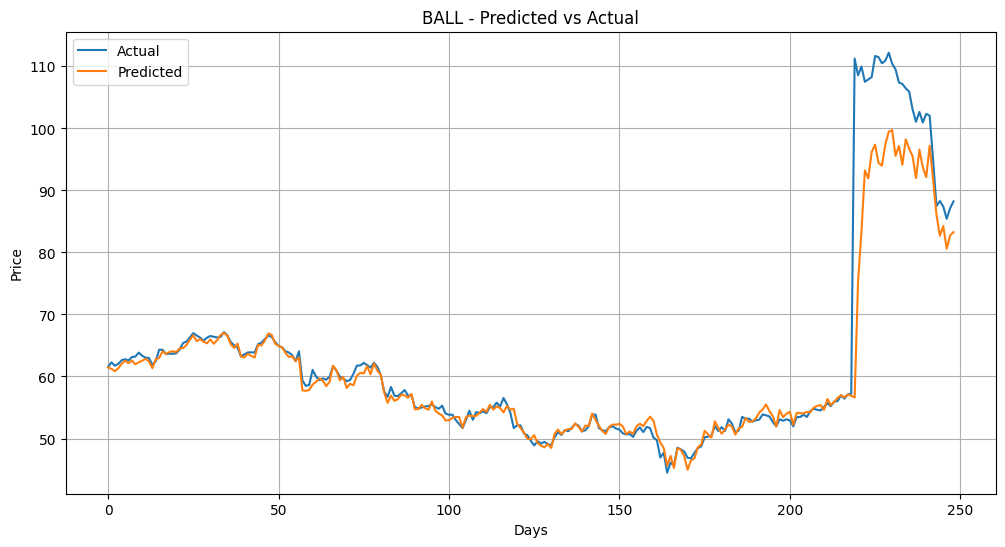

In [17]:
import matplotlib.pyplot as plt

feature_idx = 0  # e.g. Close price (adjust if needed)

plt.figure(figsize=(12,6))
plt.plot(actuals_inv[:, feature_idx], label="Actual")
plt.plot(preds_inv[:, feature_idx], label="Predicted")
plt.title(f"{sample_ticker} - Predicted vs Actual")
plt.xlabel(f"Days")
plt.ylabel(f"Price")
plt.grid()
plt.legend()
plt.show()

In [18]:
# this is to know what index the next ticker for testing
for i, meta in enumerate(val_meta):
    if meta[0] != val_meta[0][0]:
        print("First different ticker at index:", i)
        print("Ticker:", meta[0])
        break

First different ticker at index: 249
Ticker: HPE


In [19]:
# Future Price Prediction 
def predict_next_day(ticker: str):
    """
    Takes the most recent 30 days of a ticker and predicts tomorrow.
    """
    if ticker not in scalers:
        raise ValueError(f"No scaler found for {ticker}. Was it in the training data?")

    # Get the most recent SEQ_LEN rows for this ticker
    ticker_data = df[df[ticker_col] == ticker][feature_names].values
    
    if len(ticker_data) < SEQ_LEN:
        raise ValueError(f"{ticker} only has {len(ticker_data)} rows, need {SEQ_LEN}")

    # Take last 30 days
    recent_30 = ticker_data[-SEQ_LEN:]

    # Scale using this ticker's scaler
    sc = scalers[ticker]
    recent_scaled = sc.transform(recent_30)

    # Run through model
    model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
    model.eval()

    x = torch.tensor(recent_scaled, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        pred_scaled = model(x).cpu().numpy()[:, 0, :]   # (1, INPUT_DIM)

    # Inverse transform back to dollars
    pred_inv = sc.inverse_transform(pred_scaled)[0]

    # Get today's actual prices for comparison
    today_inv     = recent_30[-1]
    # today_inv = sc.inverse_transform(recent_30[-1:].reshape(1, -1))[0]

    # Get the date of the last known day and predict "next day"
    ticker_df   = df[df[ticker_col] == ticker]
    last_date   = pd.to_datetime(ticker_df["Date"].values[-1])
    next_date   = last_date + pd.Timedelta(days=1)

    # Print results
    print(f"\n Future Prediction for {ticker}")
    print(f"  Last known date : {last_date.date()}")
    print(f"  Predicting for  : {next_date.date()}")
    print(f"\n  {'':10s}  {'Today (known)':>15}  {'Tomorrow (pred)':>15}  {'Change':>10}")
    print(f"  {'─'*55}")

    for col in ["Open", "High", "Low", "Close"]:
        if col not in feature_names:
            continue
        idx     = feature_names.index(col)
        today_v = today_inv[idx]
        pred_v  = pred_inv[idx]
        change  = pred_v - today_v
        arrow   = "up" if change > 0 else "down"
        print(f"  {col:10s}  {today_v:>15.2f}  {pred_v:>15.2f}  {arrow} {abs(change):>7.2f}")

    # Volume separately (it's log-scaled)
    if "Volume" in feature_names:
        vidx       = feature_names.index("Volume")
        vol_today  = np.expm1(today_inv[vidx])    # undo log1p
        vol_pred   = np.expm1(pred_inv[vidx])
        print(f"  {'Volume':10s}  {vol_today:>15.0f}  {vol_pred:>15.0f}")

    # Direction confidence
    close_idx  = feature_names.index("Close")
    direction  = "UP " if pred_inv[close_idx] > today_inv[close_idx] else "DOWN "
    print(f"\n  Predicted direction : {direction}")

    return pred_inv


# Run for a few tickers 
for ticker in [ "BALL","MSFT", "GOOGL"]:
    try:
        predict_next_day(ticker)
    except ValueError as e:
        print(f"Skipping {ticker}: {e}")


 Future Prediction for BALL
  Last known date : 2025-06-27
  Predicting for  : 2025-06-28

                Today (known)  Tomorrow (pred)      Change
  ───────────────────────────────────────────────────────
  Open                  57.21            56.61  down    0.60
  High                  57.21            57.20  down    0.01
  Low                   56.25            56.08  down    0.17
  Close                 56.41            56.69  up    0.28
  Volume              2974400          2456324

  Predicted direction : UP 

 Future Prediction for MSFT
  Last known date : 2025-06-27
  Predicting for  : 2025-06-28

                Today (known)  Tomorrow (pred)      Change
  ───────────────────────────────────────────────────────
  Open                 497.55           486.08  down   11.47
  High                 499.30           490.30  down    9.00
  Low                  493.03           480.99  down   12.04
  Close                495.94           485.56  down   10.38
  Volume            